# Agriculural Commodities Futures and CFTC Commitment of Traders (COT) Data Analysis

## Environment and Library Setup

-------------------------------------------------------------------------------------------------------------------------------------------------------

This section imports the libraries used throughout the analysis for data manipulation, visualization, and futures price retrieval.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.ticker import PercentFormatter

## Data Acquisition and Preparation

-------------------------------------------------------------------------------------------------------------------------------------------------------

### Loading COT and Futures Price Data

The analysis combines weekly CFTC Commitment of Traders (COT) positioning data with daily commodity futures prices downloaded from Yahoo Finance.

COT data provides trader positioning information by market participant category, while futures prices are used to compute subsequent forward returns following positioning extremes.

The analysis focuses on a small set of agricultural and livestock futures markets chosen for data availability and relatively continuous COT coverage.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# Loading cleaned COT data
cot = pd.read_csv('data/cot_clean.csv', parse_dates=['date', 'tradeable_date'])
# Yahoo Finance front-month futures tickers used for return calculations.
tickers = {'corn': 'ZC=F', 'soy': 'ZS=F', 'hogs': 'HE=F','live_cattle': 'LE=F','feeder_cattle': 'GF=F'}
eod = {}
# Flatten multi-index column names returned by yfinance.
for name, ticker in tickers.items():
    df = yf.download(ticker, start='2000-01-01', auto_adjust=True, progress=False)
    df.columns = ['_'.join(col).strip('_') for col in df.columns]
    eod[name] = df

### Market Name Standardization

CFTC market names and Yahoo Finance ticker symbols use different naming conventions. So, we standardize identifiers across datasets so that positioning data can be aligned with corresponding futures price series.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
cot_market_map = {
    'CORN - CHICAGO BOARD OF TRADE': ('corn', 'ZC=F'),
    'SOYBEANS - CHICAGO BOARD OF TRADE': ('soy', 'ZS=F'),
    'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE': ('hogs', 'HE=F'),
    'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE': ('live_cattle', 'LE=F'),
    'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE': ('feeder_cattle', 'GF=F')
}

## Commercial Hedger Positioning Characteristics

-------------------------------------------------------------------------------------------------------------------------------------------------
### Market-Level Positioning Statistics


Before examining positioning extremes, it is important to understand how commercial traders typically behave in each market. Commercial participants primarily use futures contracts for hedging, and the direction of that hedging activity depends heavily on the underlying structure of the commodity market. As a result, the baseline level and direction of commercial positioning can vary substantially across contracts.

These statistics provide context for interpreting later signals. An extreme commercial short position has a different meaning in a market where commercials are net short nearly all the time than it does in a market where positioning is more balanced. Understanding the normal state of commercial participation is therefore necessary before evaluating whether unusually large positioning imbalances contain predictive information.

The selected agricultural markets are overwhelmingly characterized by commercial net-short positioning, with commercials remaining net short for more than 60% of all observations in every market except feeder cattle. This pattern is consistent with producer-dominated markets in which futures contracts are frequently used to hedge future production. Feeder cattle differs somewhat from the other contracts, potentially reflecting a larger presence of commercial participants whose primary exposure is on the consumption side of the market.

-------------------------------------------------------------------------------------------------------------------------------------------------







In [4]:
# Calculate summary statistics describing the typical scale and direction of commercial hedger positioning in each commodity market.

structure_rows = []

for cot_name, (short_name, ticker) in cot_market_map.items():
    df = cot[cot["Market and Exchange Names"] == cot_name].copy()

    avg_comm_long = df["Commercial Positions-Long (All)"].mean()
    avg_comm_short = df["Commercial Positions-Short (All)"].mean()
    avg_comm_net = df["comm_net"].mean()
    avg_open_interest = df["Open Interest (All)"].mean()
    avg_comm_share_oi = (
        (df["Commercial Positions-Long (All)"] +
         df["Commercial Positions-Short (All)"]).mean()
        / avg_open_interest
    )

    pct_weeks_net_short = (df["comm_net"] < 0).mean()

    structure_rows.append({
        "Market": short_name,
        "Avg Comm Net": avg_comm_net,
        "Avg Open Interest": avg_open_interest,
        "Commercial Participation Ratio": avg_comm_share_oi,
        "% Weeks Net Short": pct_weeks_net_short
    })

commercial_structure_df = pd.DataFrame(structure_rows)

### Summary Table Construction

-------------------------------------------------------------------------------------------------------------------------------------------------------

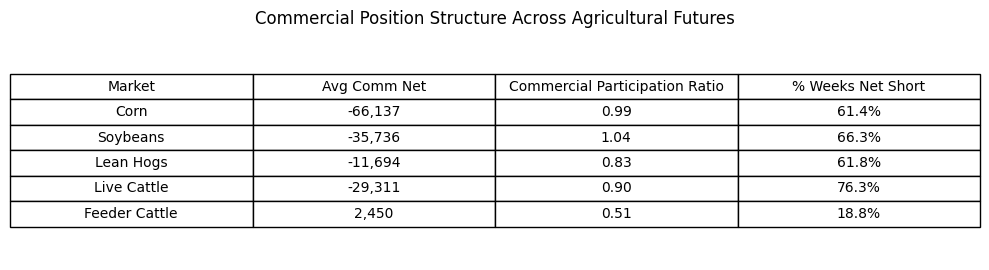

In [5]:

table_df = commercial_structure_df.copy()

display_names = {
    "corn": "Corn",
    "soy": "Soybeans",
    "hogs": "Lean Hogs",
    "live_cattle": "Live Cattle",
    "feeder_cattle": "Feeder Cattle"
}

table_df["Market"] = table_df["Market"].map(display_names)

table_df["Avg Comm Net"] = (
    table_df["Avg Comm Net"]
    .map(lambda x: f"{x:,.0f}")
)

table_df["Commercial Participation Ratio"] = (
    table_df["Commercial Participation Ratio"]
    .map(lambda x: f"{x:.2f}")
)

table_df["% Weeks Net Short"] = (
    table_df["% Weeks Net Short"]
    .map(lambda x: f"{x:.1%}")
)

table_df = table_df[
    [
        "Market",
        "Avg Comm Net",
        "Commercial Participation Ratio",
        "% Weeks Net Short"
    ]
]

# ---------------------------------
# Create matplotlib table
# ---------------------------------

fig, ax = plt.subplots(figsize=(10, 2.8))

ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title(
    "Commercial Position Structure Across Agricultural Futures",
    fontsize=12,
    pad=12
)

plt.tight_layout()
plt.show()

### Commercial Net-Short Frequency

Visualize how frequently commercial hedgers maintain net-short exposure across commodity markets.

-------------------------------------------------------------------------------------------------------------------------------------------------------

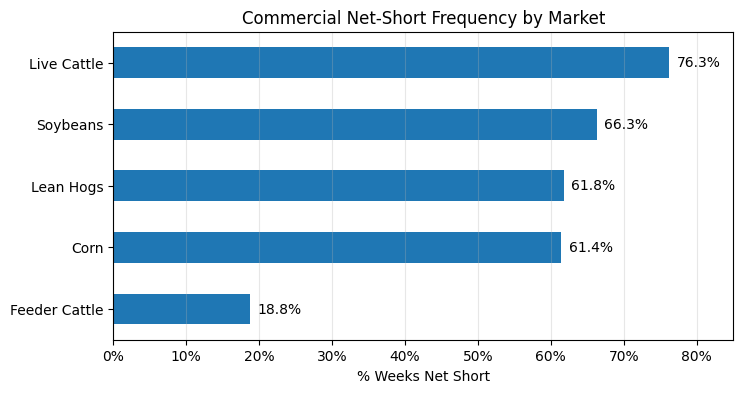

In [6]:
plot_df = commercial_structure_df.copy()

plot_df["Market"] = plot_df["Market"].map(display_names)

plot_df = plot_df.sort_values("% Weeks Net Short", ascending=True)

plot_df.plot(
    x="Market",
    y="% Weeks Net Short",
    kind="barh",
    figsize=(8,4),
    legend=False,
    title="Commercial Net-Short Frequency by Market"
)

plt.xlabel("% Weeks Net Short")
plt.ylabel("")
plt.xlim(0, 0.85)

plt.grid(axis="x", alpha=0.3)

for i, v in enumerate(plot_df["% Weeks Net Short"]):
    plt.text(v + 0.01, i, f"{v:.1%}", va='center')

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

## Signal Dataset Construction

-------------------------------------------------------------------------------------------------------------------------------------------------

### Aligning COT Releases with Daily Futures Data

Attaching the most recently available COT observation to each trading day allows us to analyze the relationship between COT positioning and daily returns.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
merged = {}

for cot_name, (short, ticker) in cot_market_map.items():

    price = eod[short].copy()

    if isinstance(price.columns, pd.MultiIndex):
        price.columns = ['_'.join(col).strip('_') for col in price.columns]

    close_col = next(c for c in price.columns if "Close" in c)
    open_col  = next(c for c in price.columns if "Open" in c)

    price["ret"] = price[close_col].pct_change()
    price["oc_ret"] = (price[close_col] - price[open_col]) / price[open_col]

    cot_mkt = cot[cot["Market and Exchange Names"] == cot_name][
        ["tradeable_date", "cot_idx", "spec_idx", "oi_idx"]
    ].copy()

    price = price.reset_index()
    price["Date"] = price["Date"].astype("datetime64[s]")
    cot_mkt["tradeable_date"] = cot_mkt["tradeable_date"].astype("datetime64[s]")

    merged_df = pd.merge_asof(
        price.sort_values("Date"),
        cot_mkt.sort_values("tradeable_date"),
        left_on="Date",
        right_on="tradeable_date",
        direction="backward"
    ).set_index("Date")

    merged_df = merged_df.dropna(
        subset=["cot_idx", "spec_idx", "oi_idx"]
    )

    merged_df["overnight"] = (
        merged_df["ret"] - merged_df["oc_ret"]
    )

    merged[short] = merged_df

## Positioning State Analysis
-------------------------------------------------------------------------------------------------------------------------------------------------------

### COT Quintile Analysis

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [9]:
horizon = 30
rows = []

market_labels = {
    "corn": "Corn",
    "soy": "Soybeans",
    "hogs": "Lean Hogs",
    "live_cattle": "Live Cattle",
    "feeder_cattle": "Feeder Cattle",
}

for market, label in market_labels.items():
    d = merged[market].loc['2008':].copy()

    close_col = next(c for c in d.columns if "Close" in c)
    d['fwd_ret'] = d[close_col].shift(-horizon) / d[close_col] - 1

    tmp = d[['cot_idx', 'fwd_ret']].dropna().copy()
    tmp['bucket'] = pd.qcut(
        tmp['cot_idx'],
        5,
        labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'],
        duplicates='drop'
    )

    summary = (
        tmp.groupby('bucket', observed=False)['fwd_ret']
        .agg(['mean', 'count'])
        .reset_index()
    )
    summary['win_rate'] = (
        tmp.groupby('bucket', observed=False)['fwd_ret']
        .apply(lambda x: (x > 0).mean())
        .values
    )
    summary['market'] = label

    rows.append(summary)

bucket_results = pd.concat(rows, ignore_index=True)

### Mean forward returns by COT Index quintile.
-------------------------------------------------------------------------------------------------------------------------------------------------------

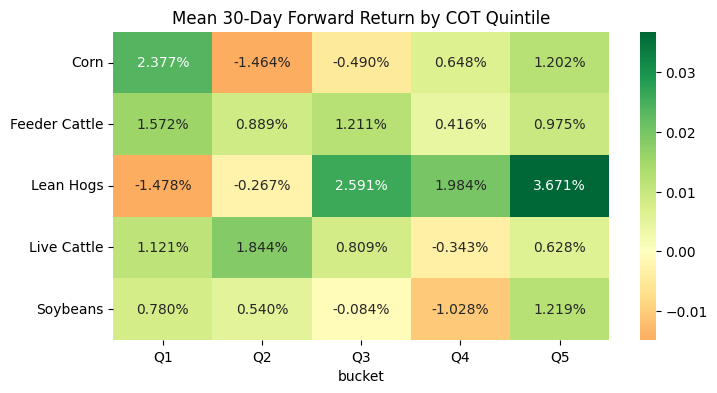

In [10]:
heat = bucket_results.pivot(index='market', columns='bucket', values='mean')

plt.figure(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt=".3%", cmap="RdYlGn", center=0)
plt.title("Mean 30-Day Forward Return by COT Quintile")
plt.ylabel("")
plt.show()


### Win rates by COT Index quintile.
-------------------------------------------------------------------------------------------------------------------------------------------------------

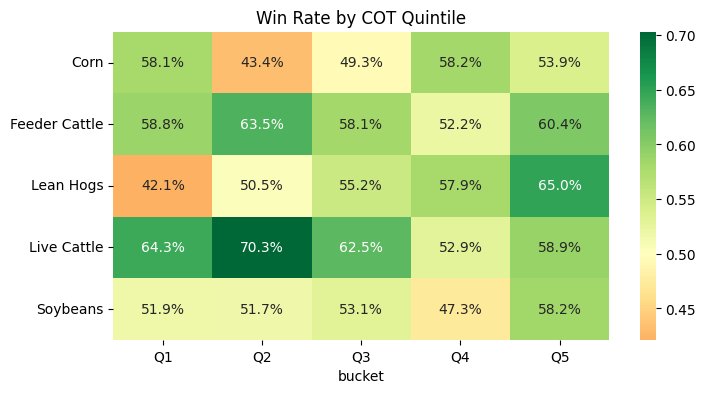

In [11]:
heat_wr = bucket_results.pivot(index='market', columns='bucket', values='win_rate')

plt.figure(figsize=(8, 4))
sns.heatmap(heat_wr, annot=True, fmt=".1%", cmap="RdYlGn", center=0.5)
plt.title("Win Rate by COT Quintile")
plt.ylabel("")
plt.show()



## Signal Identification
-------------------------------------------------------------------------------------------------------------------------------------------------------

### Tail Event Characteristics

To better understand the behavior of extreme positioning regimes, tail events are examined separately. For each upper- and lower-tail entry, the analysis records the average duration of the positioning regime as well as the largest upward and downward price excursions observed within the subsequent 120 trading days. This provides a descriptive view of how extreme positioning states evolve after they emerge.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [69]:
max_horizon = 120

rows = []

for market, label in market_labels.items():

    d = merged[market].loc['2008':].copy()
    close_col = next(c for c in d.columns if "Close" in c)

    d["upper_tail"] = d["cot_idx"] >= 0.8
    d["lower_tail"] = d["cot_idx"] <= 0.2

    prev_upper = d["upper_tail"].shift(1, fill_value=False)
    prev_lower = d["lower_tail"].shift(1, fill_value=False)

    d["upper_entry"] = d["upper_tail"] & (~prev_upper)
    d["lower_entry"] = d["lower_tail"] & (~prev_lower)

    signal_specs = [
        ("upper", "upper_tail", "upper_entry"),
        ("lower", "lower_tail", "lower_entry"),
    ]

    for tail_name, tail_col, entry_col in signal_specs:

        entry_locs = np.where(d[entry_col].values)[0]

        durations = []

        max_up_days = []
        max_up_returns = []

        max_down_days = []
        max_down_returns = []

        for loc in entry_locs:

            # cluster duration
            run_len = 0
            j = loc

            while j < len(d) and bool(d[tail_col].iloc[j]):
                run_len += 1
                j += 1

            durations.append(run_len)

            if loc + max_horizon >= len(d):
                continue

            future_prices = d[close_col].iloc[
                loc : loc + max_horizon + 1
            ]

            rel_path = future_prices / future_prices.iloc[0] - 1

            up_idx = rel_path.values.argmax()
            down_idx = rel_path.values.argmin()

            max_up_days.append(int(up_idx))
            max_up_returns.append(float(rel_path.iloc[up_idx]))

            max_down_days.append(int(down_idx))
            max_down_returns.append(float(rel_path.iloc[down_idx]))

        rows.append({
            "Market": label,
            "Tail": tail_name,
            "Events": len(entry_locs),

            "Avg Cluster Days":
                np.mean(durations) if durations else np.nan,

            "Avg Max Up":
                np.mean(max_up_returns) if max_up_returns else np.nan,

            "Avg Day to Max Up":
                np.mean(max_up_days) if max_up_days else np.nan,

            "Avg Max Down":
                np.mean(max_down_returns) if max_down_returns else np.nan,

            "Avg Day to Max Down":
                np.mean(max_down_days) if max_down_days else np.nan,
        })

tail_excursion_summary = pd.DataFrame(rows)

(
    tail_excursion_summary.style
    .format({
        "Events": "{:.0f}",
        "Avg Cluster Days": "{:.1f}",
        "Avg Max Up": "{:.2%}",
        "Avg Day to Max Up": "{:.1f}",
        "Avg Max Down": "{:.2%}",
        "Avg Day to Max Down": "{:.1f}",
    })
    .hide(axis="index")
)

Market,Tail,Events,Avg Cluster Days,Avg Max Up,Avg Day to Max Up,Avg Max Down,Avg Day to Max Down
Corn,upper,37,38.6,16.91%,71.7,-13.86%,69.2
Corn,lower,22,46.6,14.39%,34.4,-18.85%,69.8
Soybeans,upper,37,32.6,12.32%,59.8,-10.49%,63.6
Soybeans,lower,32,37.8,13.82%,57.5,-12.43%,68.1
Lean Hogs,upper,30,34.6,29.54%,72.7,-14.59%,50.2
Lean Hogs,lower,26,43.2,19.29%,61.4,-14.91%,59.5
Live Cattle,upper,38,31.8,9.67%,71.0,-6.37%,37.4
Live Cattle,lower,29,42.7,12.49%,86.6,-4.83%,33.4
Feeder Cattle,upper,37,31.9,10.17%,73.1,-7.56%,49.6
Feeder Cattle,lower,25,45.0,11.02%,67.3,-7.55%,50.9



### Return Path Analysis of Tail-Entry Signals

Tail states identified in the previous analysis are examined individually to assess their tradeability. Cumulative favorable return paths are plotted following signal entry, allowing comparison of persistence, timing, and consistency across candidate signals. This analysis was used to guide signal selection and holding-period determination.

-------------------------------------------------------------------------------------------------------------------------------------------------------

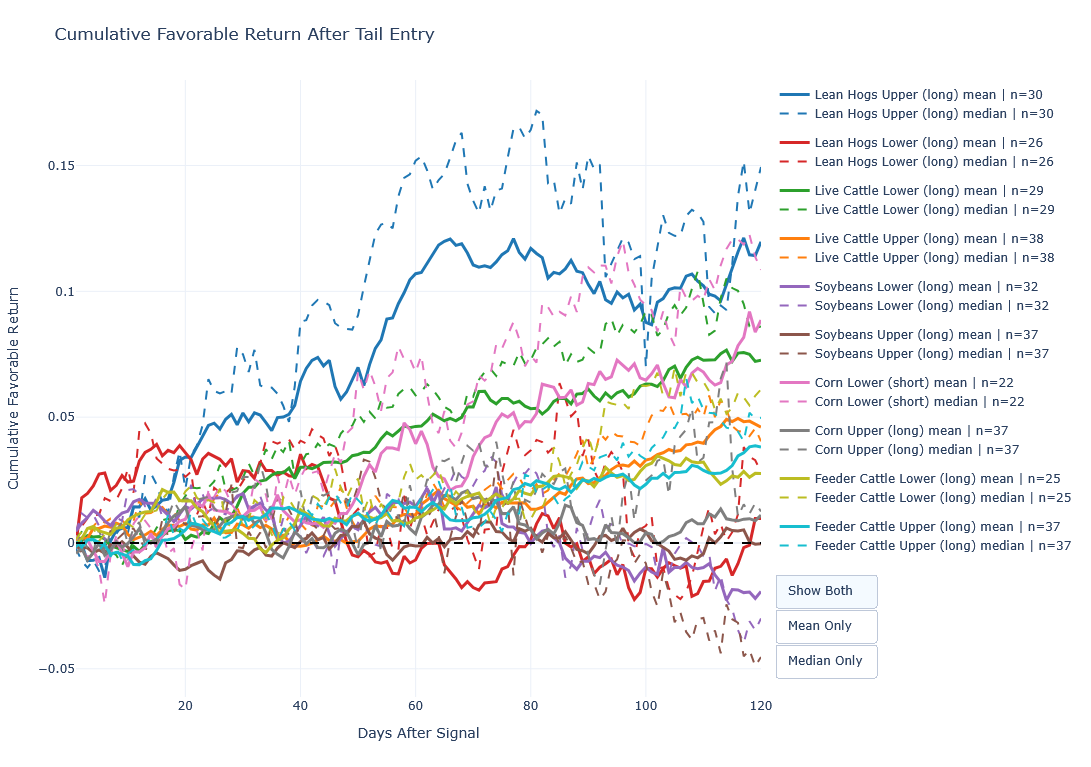

In [70]:
max_horizon = 120

signal_specs = [
    ("hogs", "Lean Hogs Upper", "upper", "long"),
    ("hogs", "Lean Hogs Lower", "lower", "long"),
    ("live_cattle", "Live Cattle Lower", "lower", "long"),
    ("live_cattle", "Live Cattle Upper", "upper", "long"),
    ("soy", "Soybeans Lower", "lower", "long"),
    ("soy", "Soybeans Upper", "upper", "long"),
    ("corn", "Corn Lower", "lower", "short"),
    ("corn", "Corn Upper", "upper", "long"),
    ("feeder_cattle", "Feeder Cattle Lower", "lower", "long"),
    ("feeder_cattle", "Feeder Cattle Upper", "upper", "long"),
]

series_data = []

for market, label, tail, direction in signal_specs:
    d = merged[market].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    d["ret"] = d[close_col].pct_change()

    if tail == "upper":
        d["tail_state"] = d["cot_idx"] >= 0.8
    else:
        d["tail_state"] = d["cot_idx"] <= 0.2

    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry"] = d["tail_state"] & (~prev_state)

    entry_locs = np.where(d["entry"].values)[0]
    paths = []

    for loc in entry_locs:
        if loc + max_horizon >= len(d):
            continue

        future = d["ret"].iloc[loc + 1 : loc + 1 + max_horizon].values
        path = np.cumsum(future)

        if direction == "short":
            path = -path

        paths.append(path)

    if len(paths) == 0:
        continue

    paths = np.array(paths)

    series_data.append({
        "name": f"{label} ({direction})",
        "mean": paths.mean(axis=0),
        "median": np.median(paths, axis=0),
        "n": len(paths),
    })

fig = go.Figure()
x = np.arange(1, max_horizon + 1)

colors = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#ff7f0e",  # orange
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
]

for i, s in enumerate(series_data):
    color = colors[i % len(colors)]
    group = s["name"]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=s["mean"],
            mode="lines",
            name=f"{s['name']} mean | n={s['n']}",
            legendgroup=group,
            line=dict(color=color, width=3, dash="solid"),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Day %{x}<br>"
                "Return %{y:.2%}<extra></extra>"
            ),
            visible=True,
        )
    )

    fig.add_trace(
        go.Scatter(
            x=x,
            y=s["median"],
            mode="lines",
            name=f"{s['name']} median | n={s['n']}",
            legendgroup=group,
            line=dict(color=color, width=2, dash="dash"),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Day %{x}<br>"
                "Return %{y:.2%}<extra></extra>"
            ),
            visible=True,
        )
    )

n_signals = len(series_data)
both_visible = [True, True] * n_signals
mean_only = []
median_only = []

for _ in range(n_signals):
    mean_only.extend([True, False])
    median_only.extend([False, True])

fig.update_layout(
    title="Cumulative Favorable Return After Tail Entry",
    xaxis_title="Days After Signal",
    yaxis_title="Cumulative Favorable Return",
    hovermode="x unified",
    template="plotly_white",
    width=1100,
    height=750,
    margin=dict(l=70, r=260, t=80, b=70),
    updatemenus=[
        {
            "type": "buttons",
            "direction": "down",
            "x": 1.02,
            "y": 0.2,
            "xanchor": "left",
            "yanchor": "top",
            "showactive": True,
            "buttons": [
                {
                    "label": "Show Both",
                    "method": "update",
                    "args": [
                        {"visible": both_visible},
                        {"title": "Cumulative Favorable Return After Tail Entry"},
                    ],
                },
                {
                    "label": "Mean Only",
                    "method": "update",
                    "args": [
                        {"visible": mean_only},
                        {"title": "Mean Cumulative Favorable Return After Tail Entry"},
                    ],
                },
                {
                    "label": "Median Only",
                    "method": "update",
                    "args": [
                        {"visible": median_only},
                        {"title": "Median Cumulative Favorable Return After Tail Entry"},
                    ],
                },
            ],
        }
    ],
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1.0,
        xanchor="left",
        x=1.02
    ),
)

fig.add_hline(y=0, line_dash="dash", line_color="black")

fig.show()

### Entry Timing Analysis

Inspection of the cumulative return paths suggested that several signals experience short-term reversals or periods of consolidation immediately following tail entry. To evaluate whether entry timing affects performance, each candidate signal is tested using a series of delayed-entry rules. This analysis helps identify whether the signal's return profile develops immediately or after an initial adjustment period.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [71]:
signal_specs = [
    {
        "Signal": "Lean Hogs upper long",
        "market": "hogs",
        "tail": "upper",
        "direction": "long",
        "eval_horizon": 75,
    },
    {
        "Signal": "Lean Hogs lower long",
        "market": "hogs",
        "tail": "lower",
        "direction": "long",
        "eval_horizon": 15,
    },
    {
        "Signal": "Live Cattle lower long",
        "market": "live_cattle",
        "tail": "lower",
        "direction": "long",
        "eval_horizon": 120,
    },
    {
        "Signal": "Soy lower long",
        "market": "soy",
        "tail": "lower",
        "direction": "long",
        "eval_horizon": 30,
    },
    {
        "Signal": "Corn lower short",
        "market": "corn",
        "tail": "lower",
        "direction": "short",
        "eval_horizon": 120,
    },
]

entry_rules = [
    ("Day 0",   0),
    ("Day +5",  5),
    ("Day +10", 10),
    ("Day +15", 15),
]

def build_signal_frame(spec):
    d = merged[spec["market"]].loc["2008":].copy()
    close_col = next(c for c in d.columns if "Close" in c)
    if spec["tail"] == "upper":
        d["tail_state"] = (d["cot_idx"] >= 0.8).astype(bool)
    else:
        d["tail_state"] = (d["cot_idx"] <= 0.2).astype(bool)
    prev_state = d["tail_state"].shift(1, fill_value=False)
    d["entry_event"] = d["tail_state"] & (~prev_state)
    return d, close_col

all_results = []

for spec in signal_specs:
    d, close_col = build_signal_frame(spec)
    event_locs = np.where(d["entry_event"].values)[0]
    signal_rows = []

    for entry_label, lag_days in entry_rules:
        trade_returns = []
        trade_mfe     = []
        trade_peak_day = []

        for signal_loc in event_locs:
            entry_loc = signal_loc + lag_days
            exit_loc  = signal_loc + spec["eval_horizon"]

            # need enough room for both entry and exit
            if entry_loc >= len(d) or exit_loc >= len(d):
                continue
            # skip if lag has already consumed the horizon
            if entry_loc >= exit_loc:
                continue

            entry_price = d[close_col].iloc[entry_loc]
            window      = d[close_col].iloc[entry_loc : exit_loc + 1]
            raw_path    = window / entry_price - 1
            fav_path    = raw_path if spec["direction"] == "long" else -raw_path

            trade_returns.append(float(fav_path.iloc[-1]))
            trade_mfe.append(float(fav_path.max()))
            trade_peak_day.append(int(fav_path.values.argmax()))

        signal_rows.append({
            "Entry":        entry_label,
            "Lag Days":     lag_days,
            "Window (days)": spec["eval_horizon"] - lag_days,
            "n Trades":     len(trade_returns),
            "Mean Return":  np.mean(trade_returns)               if trade_returns else np.nan,
            "Median Return":np.median(trade_returns)             if trade_returns else np.nan,
            "Win Rate":     np.mean(np.array(trade_returns) > 0) if trade_returns else np.nan,
            "Avg Peak Day": np.mean(trade_peak_day)              if trade_peak_day else np.nan,
        })

    signal_df = pd.DataFrame(signal_rows).set_index("Entry")

    # format for display
    fmt = {
        "Mean Return":   "{:.2%}",
        "Median Return": "{:.2%}",
        "Win Rate":      "{:.1%}",
        "Avg Peak Day":  "{:.1f}",
    }
    display(Markdown(f"### {spec['Signal']}  —  horizon: {spec['eval_horizon']}d  |  direction: {spec['direction']}"))
    display(signal_df.style.format(fmt, na_rep="—"))

    all_results.append(signal_df.assign(Signal=spec["Signal"]))
# maybe remove the avg mfe or avg peak day. not sure.

### Lean Hogs upper long  —  horizon: 75d  |  direction: long

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg Peak Day
Entry,,,,,,,
Day 0,0,75,30,11.54%,12.84%,66.7%,49.2
Day +5,5,70,30,11.94%,15.15%,73.3%,45.8
Day +10,10,65,30,10.95%,14.32%,70.0%,41.0
Day +15,15,60,30,10.51%,9.05%,66.7%,38.5


### Lean Hogs lower long  —  horizon: 15d  |  direction: long

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg Peak Day
Entry,,,,,,,
Day 0,0,15,26,4.04%,3.16%,65.4%,8.4
Day +5,5,10,26,1.22%,1.58%,61.5%,5.8
Day +10,10,5,26,1.52%,1.55%,57.7%,3.0
Day +15,15,0,0,—,—,—,—


### Live Cattle lower long  —  horizon: 120d  |  direction: long

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg Peak Day
Entry,,,,,,,
Day 0,0,120,29,7.16%,8.62%,82.8%,86.6
Day +5,5,115,29,6.89%,6.72%,82.8%,82.0
Day +10,10,110,29,7.55%,9.30%,79.3%,78.6
Day +15,15,105,29,7.12%,8.90%,82.8%,73.6


### Soy lower long  —  horizon: 30d  |  direction: long

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg Peak Day
Entry,,,,,,,
Day 0,0,30,32,1.95%,1.16%,59.4%,16.0
Day +5,5,25,32,0.80%,0.63%,59.4%,12.6
Day +10,10,20,32,0.62%,1.08%,59.4%,9.8
Day +15,15,15,32,0.40%,0.48%,53.1%,8.3


### Corn lower short  —  horizon: 120d  |  direction: short

,Lag Days,Window (days),n Trades,Mean Return,Median Return,Win Rate,Avg Peak Day
Entry,,,,,,,
Day 0,0,120,22,6.83%,11.80%,81.8%,69.8
Day +5,5,115,22,7.42%,14.06%,81.8%,65.7
Day +10,10,110,22,7.73%,12.80%,81.8%,61.8
Day +15,15,105,22,7.04%,9.29%,81.8%,57.2


### Signal vs. Unconditional Benchmark

Candidate signals identified in the previous analysis are compared against unconditional rolling returns with matching holding horizons. This benchmark helps distinguish whether performance is associated with the positioning signal itself or simply reflects the baseline return characteristics of the underlying market. Signals that fail to improve upon unconditional returns are excluded from further consideration.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [72]:
selected_lags = {
    "Lean Hogs upper long":   5,
    "Lean Hogs lower long":   0,
    "Live Cattle lower long": 10,
    "Soy lower long":        0,
    "Corn lower short":       0,
}

def rolling_unconditional(d, close_col, horizon, direction):
    closes = d[close_col].values
    returns = []
    for i in range(len(closes) - horizon):
        entry_price = closes[i]
        exit_price  = closes[i + horizon]
        r = exit_price / entry_price - 1
        if direction == "short":
            r = -r
        returns.append(r)
    returns = np.array(returns)
    return {
        "Uncond. Mean":    np.mean(returns),
        "Uncond. Median":  np.median(returns),
        "Uncond. Win Rate": np.mean(returns > 0),
        "Uncond. n":       len(returns),
    }

rows = []

for spec in signal_specs:
    d, close_col = build_signal_frame(spec)
    event_locs   = np.where(d["entry_event"].values)[0]
    lag_days     = selected_lags[spec["Signal"]]

    # --- signal stats at selected lag ---
    trade_returns = []
    for signal_loc in event_locs:
        entry_loc = signal_loc + lag_days
        exit_loc  = signal_loc + spec["eval_horizon"]
        if entry_loc >= len(d) or exit_loc >= len(d):
            continue
        if entry_loc >= exit_loc:
            continue
        entry_price = d[close_col].iloc[entry_loc]
        window      = d[close_col].iloc[entry_loc : exit_loc + 1]
        raw_path    = window / entry_price - 1
        fav_path    = raw_path if spec["direction"] == "long" else -raw_path
        trade_returns.append(float(fav_path.iloc[-1]))

    trade_returns = np.array(trade_returns)

    # --- unconditional benchmark ---
    bench = rolling_unconditional(d, close_col, spec["eval_horizon"], spec["direction"])

    rows.append({
        "Signal":            spec["Signal"],
        "Direction":         spec["direction"],
        "Horizon":           spec["eval_horizon"],
        "Selected Lag":      f"Day +{lag_days}",
        "Signal n":          len(trade_returns),
        "Signal Mean":       np.mean(trade_returns)               if len(trade_returns) else np.nan,
        "Signal Median":     np.median(trade_returns)             if len(trade_returns) else np.nan,
        "Signal Win Rate":   np.mean(trade_returns > 0)           if len(trade_returns) else np.nan,
        "Uncond. n":         bench["Uncond. n"],
        "Uncond. Mean":      bench["Uncond. Mean"],
        "Uncond. Median":    bench["Uncond. Median"],
        "Uncond. Win Rate":  bench["Uncond. Win Rate"],
        "Edge (Mean)":       np.mean(trade_returns) - bench["Uncond. Mean"] if len(trade_returns) else np.nan,
        "Edge (Median)":     np.median(trade_returns) - bench["Uncond. Median"] if len(trade_returns) else np.nan,
    })

comparison_df = pd.DataFrame(rows).set_index("Signal")

fmt = {
    "Signal Mean":      "{:.2%}",
    "Signal Median":    "{:.2%}",
    "Signal Win Rate":  "{:.1%}",
    "Uncond. Mean":     "{:.2%}",
    "Uncond. Median":   "{:.2%}",
    "Uncond. Win Rate": "{:.1%}",
    "Edge (Mean)":      "{:.2%}",
    "Edge (Median)":    "{:.2%}",
}

display(Markdown("## Signal vs. Unconditional Rolling Benchmark"))
display(comparison_df.style.format(fmt, na_rep="—")
        .background_gradient(subset=["Edge (Mean)", "Edge (Median)"], cmap="RdYlGn", axis=0))

## Signal vs. Unconditional Rolling Benchmark

,Direction,Horizon,Selected Lag,Signal n,Signal Mean,Signal Median,Signal Win Rate,Uncond. n,Uncond. Mean,Uncond. Median,Uncond. Win Rate,Edge (Mean),Edge (Median)
Signal,,,,,,,,,,,,,
Lean Hogs upper long,long,75,Day +5,30,11.94%,15.15%,73.3%,4559,2.95%,1.03%,51.5%,8.99%,14.12%
Lean Hogs lower long,long,15,Day +0,26,4.04%,3.16%,65.4%,4619,0.68%,1.03%,55.4%,3.36%,2.13%
Live Cattle lower long,long,120,Day +10,29,7.55%,9.30%,79.3%,4512,3.17%,4.18%,65.1%,4.38%,5.12%
Soy lower long,long,30,Day +0,32,1.95%,1.16%,59.4%,4605,0.28%,0.42%,52.4%,1.66%,0.74%
Corn lower short,short,120,Day +0,22,6.83%,11.80%,81.8%,4513,-1.46%,2.38%,55.1%,8.29%,9.42%


## Portfolio Construction
-------------------------------------------------------------------------------------------------------------------------------------------------------



### Portfolio Configuration

The selected signals are combined into a portfolio using fixed fractional position sizing. Each signal may hold up to three concurrent tranches, with capital allocated evenly across active tranches. Trades are entered according to the signal-specific lag and held for the previously selected evaluation horizons.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [73]:
signal_configs = [
    {
        "Signal":       "Lean Hogs upper long",
        "market":       "hogs",
        "tail":         "upper",
        "direction":    "long",
        "entry_lag":    5,
        "eval_horizon": 75,
    },
    {
        "Signal":       "Lean Hogs lower long",
        "market":       "hogs",
        "tail":         "lower",
        "direction":    "long",
        "entry_lag":    0,
        "eval_horizon": 15,
    },
    {
        "Signal":       "Live Cattle lower long",
        "market":       "live_cattle",
        "tail":         "lower",
        "direction":    "long",
        "entry_lag":    10,
        "eval_horizon": 120,
    },
    {
        "Signal":       "Soy lower long",
        "market":       "soy",
        "tail":         "lower",
        "direction":    "long",
        "entry_lag":    0,
        "eval_horizon": 30,
    },
    {
        "Signal":       "Corn lower short",
        "market":       "corn",
        "tail":         "lower",
        "direction":    "short",
        "entry_lag":    10,
        "eval_horizon": 120,
    },
]

MAX_TRANCHES       = 3
SIGNAL_ALLOCATION  = 0.5
TRANCHE_ALLOCATION = SIGNAL_ALLOCATION / MAX_TRANCHES

### Portfolio Backtest Engine

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
all_trades  = []
daily_pnl   = {}
wealth_index   = 1.0
wealth_history = {}

signal_state = {
    cfg["Signal"]: {"open_tranches": []}
    for cfg in signal_configs
}

all_events = []
for cfg in signal_configs:
    d, close_col = build_signal_frame(cfg)
    prices       = d[close_col]
    event_locs   = np.where(d["entry_event"].values)[0]
    for sig_loc in event_locs:
        all_events.append((d.index[sig_loc], sig_loc, cfg, d, close_col, prices))

all_events.sort(key=lambda x: x[0])

for (sig_date, sig_loc, cfg, d, close_col, prices) in all_events:
    direction = cfg["direction"]
    lag       = cfg["entry_lag"]
    horizon   = cfg["eval_horizon"]
    sig_name  = cfg["Signal"]

    entry_loc = sig_loc + lag
    exit_loc  = sig_loc + horizon

    if entry_loc >= len(d) or exit_loc >= len(d):
        continue
    if entry_loc >= exit_loc:
        continue

    state = signal_state[sig_name]
    state["open_tranches"] = [t for t in state["open_tranches"] if t > entry_loc]
    if len(state["open_tranches"]) >= MAX_TRANCHES:
        continue

    state["open_tranches"].append(exit_loc)

    entry_wealth     = wealth_index
    tranche_notional = TRANCHE_ALLOCATION * entry_wealth

    entry_price = prices.iloc[entry_loc]
    exit_price  = prices.iloc[exit_loc]
    ret         = (exit_price / entry_price - 1) * (1 if direction == "long" else -1)

    pnl          = tranche_notional * ret
    wealth_index = wealth_index + pnl
    wealth_history[d.index[exit_loc]] = wealth_index

    sized_ret   = TRANCHE_ALLOCATION * ret

    actual_hold = exit_loc - entry_loc
    for day_offset in range(1, actual_hold + 1):
        day_loc = entry_loc + day_offset
        if day_loc >= len(d):
            break
        day_date   = d.index[day_loc]
        prev_price = prices.iloc[day_loc - 1]
        curr_price = prices.iloc[day_loc]
        daily_ret  = (curr_price / prev_price - 1) * (1 if direction == "long" else -1)
        daily_pnl[day_date] = daily_pnl.get(day_date, 0.0) + TRANCHE_ALLOCATION * daily_ret

    all_trades.append({
        "Signal":       sig_name,
        "Entry Date":   d.index[entry_loc],
        "Exit Date":    d.index[exit_loc],
        "Entry Lag":    lag,
        "Horizon":      actual_hold,
        "Direction":    direction,
        "Entry Price":  entry_price,
        "Exit Price":   exit_price,
        "Raw Return":   ret,
        "Entry Wealth": entry_wealth,
        "Notional":     tranche_notional,
        "PnL":          pnl,
        "Alloc":        TRANCHE_ALLOCATION,
        "Sized Return": sized_ret,
        "Win":          ret > 0,
        "Tranche":      len(state["open_tranches"]),
    })



## Portfolio Results

-------------------------------------------------------------------------------------------------------------------------------------------------------

### Portfolio Risk and Performance Metrics

Portfolio performance is evaluated using a daily mark-to-market wealth series constructed from all active positions. Standard performance metrics, including CAGR, Sharpe ratio, Sortino ratio, Calmar ratio, maximum drawdown, and trade expectancy, are reported.

-------------------------------------------------------------------------------------------------------------------------------------------------------

In [75]:
# ── Trade log ─────────────────────────────────────────────────────────────
trade_df = pd.DataFrame(all_trades).sort_values("Entry Date").reset_index(drop=True)
trade_df["Entry Date"] = pd.to_datetime(trade_df["Entry Date"])
trade_df["Exit Date"]  = pd.to_datetime(trade_df["Exit Date"])

# ── Wealth series (trade-exit compounding) ────────────────────────────────
wealth_series      = pd.Series(wealth_history).sort_index()
wealth_series.name = "Wealth Index"

# ── Daily return series (risk metrics) ───────────────────────────────────
eq_series = pd.Series(daily_pnl).sort_index()
eq_series = eq_series.reindex(
    pd.bdate_range(eq_series.index.min(), eq_series.index.max()), fill_value=0.0
)
wealth_daily      = (1 + eq_series).cumprod()
wealth_daily.name = "Wealth Index (Daily MTM)"

rolling_max = wealth_daily.cummax()
drawdown    = wealth_daily / rolling_max - 1
max_dd      = drawdown.min()

# ── Headline risk metrics ─────────────────────────────────────────────────
ann_factor   = np.sqrt(252)
daily_returns = eq_series.copy()

sharpe = (daily_returns.mean() / daily_returns.std() * ann_factor
          if daily_returns.std() > 0 else np.nan)

downside     = daily_returns[daily_returns < 0]
downside_std = downside.std()
sortino      = (daily_returns.mean() / downside_std * ann_factor
                if downside_std > 0 else np.nan)

years = (wealth_daily.index[-1] - wealth_daily.index[0]).days / 365.25
cagr  = (wealth_index / 1.0) ** (1 / years) - 1  # use final wealth_index directly
calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

gross_profit_raw = trade_df.loc[trade_df["Raw Return"] > 0, "Raw Return"].sum()
gross_loss_raw   = -trade_df.loc[trade_df["Raw Return"] <= 0, "Raw Return"].sum()
profit_factor    = gross_profit_raw / gross_loss_raw if gross_loss_raw > 0 else np.nan

wins       = trade_df[trade_df["Raw Return"] > 0]["Raw Return"]
losses     = trade_df[trade_df["Raw Return"] <= 0]["Raw Return"]
win_rate   = len(wins) / len(trade_df)
avg_win    = wins.mean()   if len(wins)   > 0 else 0
avg_loss   = -losses.mean() if len(losses) > 0 else 0
expectancy = win_rate * avg_win - (1 - win_rate) * avg_loss

### Portfolio Summary Statistics & Metrics
-------------------------------------------------------------------------------------------------------------------------------------------------------

## Summary Stats

Signal,n Trades,Max Tranches,Win Rate,Mean Return,Alloc/Tranche,Total PnL,Mean Sized Ret,Cumulative Contribution,Avg Hold (days)
Soy lower long,32,3,59.4%,1.95%,16.7%,0.1757,0.0032,0.1039,30
Corn lower short,22,3,81.8%,7.73%,16.7%,0.3769,0.0129,0.2834,110
Lean Hogs upper long,29,3,75.9%,12.60%,16.7%,1.4299,0.0210,0.6089,70
Live Cattle lower long,28,3,82.1%,7.83%,16.7%,1.0404,0.0131,0.3654,110
Lean Hogs lower long,26,1,65.4%,4.04%,16.7%,0.3825,0.0067,0.1751,15
ALL SIGNALS,137,3,72.3%,6.73%,—,3.4054,0.0112,1.5368,—


## Portfolio Metrics

Metric,Value
Final Wealth,4.4054x
CAGR,8.45%
Sharpe Ratio,1.09
Sortino Ratio,1.40
Calmar Ratio,0.53
Max Drawdown,-16.03%
Expectancy per Trade,6.73%
Overall Win Rate,72.3%


## Daily Mark-to-Market Portfolio Wealth

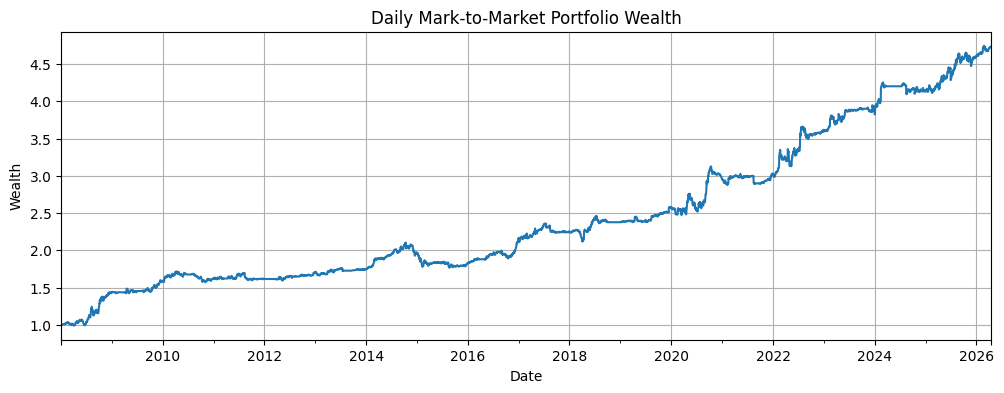

In [76]:
# ── Summary ───────────────────────────────────────────────────────────────
def summarize(df):
    rows = []
    for sig in df["Signal"].unique():
        s = df[df["Signal"] == sig]
        rows.append({
            "Signal":          sig,
            "n Trades":        len(s),
            "Max Tranches":    s["Tranche"].max(),
            "Win Rate":        s["Win"].mean(),
            "Mean Return":     s["Raw Return"].mean(),
            "Alloc/Tranche":   TRANCHE_ALLOCATION,
            "Total PnL":       s["PnL"].sum(),
            "Mean Sized Ret":  s["Sized Return"].mean(),
            "Cumulative Contribution": s["Sized Return"].sum(),
            "Avg Hold (days)": s["Horizon"].mean(),
        })
    total_row = {
        "Signal":          "ALL SIGNALS",
        "n Trades":        len(df),
        "Max Tranches":    df["Tranche"].max(),
        "Win Rate":        df["Win"].mean(),
        "Mean Return":     df["Raw Return"].mean(),
        "Alloc/Tranche":   np.nan,
        "Total PnL":       df["PnL"].sum(),
        "Mean Sized Ret":  df["Sized Return"].mean(),
        "Cumulative Contribution": df["Sized Return"].sum(),
        "Avg Hold (days)": np.nan,
    }
    return pd.concat([pd.DataFrame(rows), pd.DataFrame([total_row])], ignore_index=True)

summary_df = summarize(trade_df)

# ── Display ───────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Metric": [
        "Final Wealth",
        "CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Calmar Ratio",
        "Max Drawdown",
        "Expectancy per Trade",
        "Overall Win Rate",
    ],
    "Value": [
        f"{wealth_index:.4f}x",
        f"{cagr:.2%}",
        f"{sharpe:.2f}",
        f"{sortino:.2f}",
        f"{calmar:.2f}",
        f"{max_dd:.2%}",
        f"{expectancy:.2%}",
        f"{win_rate:.1%}",
    ]
})

display(Markdown("## Summary Stats"))
fmt = {
    "Win Rate":        "{:.1%}",
    "Mean Return":     "{:.2%}",
    "Alloc/Tranche":   "{:.1%}",
    "Total PnL":       "{:.4f}",
    "Mean Sized Ret":  "{:.4f}",
    "Cumulative Contribution": "{:.4f}",
    "Avg Hold (days)": "{:.0f}",
}

display(
    summary_df.style
        .hide(axis="index")
        .format(fmt, na_rep="—")
)

display(Markdown("## Portfolio Metrics"))
display(
    metrics_df.style.hide(axis="index")
)

display(Markdown("## Daily Mark-to-Market Portfolio Wealth"))
_ = wealth_daily.plot(
    title="Daily Mark-to-Market Portfolio Wealth",
    figsize=(12, 4),
    ylabel="Wealth",
    xlabel="Date",
    grid=True,
)

## Portfolio Diagnostics
-------------------------------------------------------------------------------------------------------------------------------------------------------

The final portfolio is evaluated beyond traditional performance statistics. Exposure patterns, signal overlap, drawdown characteristics, and position-sizing sensitivity are examined to better understand how the strategy behaves through time and how capital is deployed across signals.

-------------------------------------------------------------------------------------------------------------------------------------------------------

## Exposure & Risk

Metric,Value
Max Gross Exposure,100.00%
Max Net Exposure,83.33%
Max Concurrent Positions,4
,
% Days With Active Positions,90.2%
Avg Idle Duration (days),20.4
Avg Gross Exposure,32.70%
,
Worst Single Day,-3.51%
Worst 5-Day Loss,-5.87%


## Signal Overlap Correlation Matrix

,Soy lower long,Corn lower short,Lean Hogs upper long,Live Cattle lower long,Lean Hogs lower long
Soy lower long,1.00,0.04,-0.06,0.04,-0.04
Corn lower short,0.04,1.00,-0.15,-0.13,-0.07
Lean Hogs upper long,-0.06,-0.15,1.00,-0.09,-0.08
Live Cattle lower long,0.04,-0.13,-0.09,1.00,-0.09
Lean Hogs lower long,-0.04,-0.07,-0.08,-0.09,1.00


## Position Sizing Sensitivity

,Return Scale,CAGR,Max Drawdown,Calmar
0,0.25,2.20%,-4.21%,0.52
1,0.50,4.41%,-8.29%,0.53
2,1.00,8.85%,-16.03%,0.55


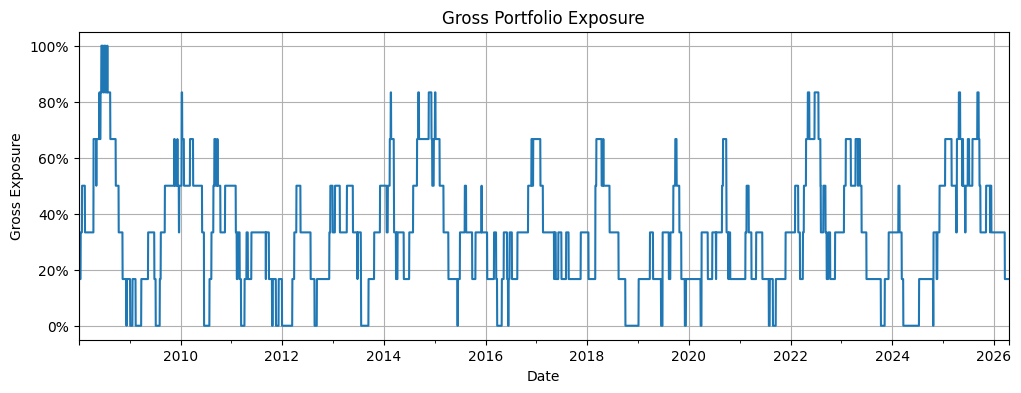

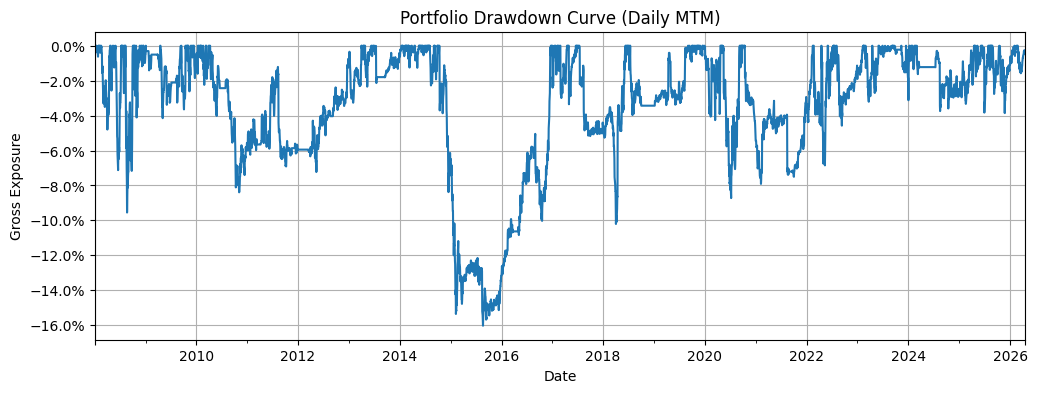

In [77]:
# assumes trade_df, eq_series, wealth_daily, wealth_index from backtest cell

# =========================================================
# 0. ASSET MAPPING
# =========================================================
signal_to_asset = {
    "Lean Hogs upper long":   "Lean Hogs",
    "Lean Hogs lower long":   "Lean Hogs",
    "Live Cattle lower long": "Live Cattle",
    "Soy lower long":        "Soy",
    "Corn lower short":       "Corn",
}

trade_df["Asset"] = trade_df["Signal"].map(signal_to_asset)

# guard against unmapped signals
unmapped = trade_df["Asset"].isna().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} trades have unmapped asset — check signal_to_asset keys")

# =========================================================
# 1. DAILY ACTIVE POSITION MATRIX
# =========================================================
calendar     = pd.bdate_range(trade_df["Entry Date"].min(), trade_df["Exit Date"].max())
signal_names = trade_df["Signal"].unique()
active_matrix = pd.DataFrame(0.0, index=calendar, columns=signal_names)
signed_matrix = pd.DataFrame(0.0, index=calendar, columns=signal_names)

for _, row in trade_df.iterrows():
    days  = pd.bdate_range(row["Entry Date"], row["Exit Date"])
    alloc = row["Alloc"]
    sign  = 1 if row["Direction"] == "long" else -1
    active_matrix.loc[days, row["Signal"]] += abs(alloc)
    signed_matrix.loc[days, row["Signal"]] += sign * alloc

# =========================================================
# 2. ASSET-LEVEL EXPOSURE MATRIX
# =========================================================
valid_trades = trade_df.dropna(subset=["Asset"])
asset_names  = valid_trades["Asset"].unique()
asset_matrix = pd.DataFrame(0.0, index=calendar, columns=asset_names)

for _, row in valid_trades.iterrows():
    days  = pd.bdate_range(row["Entry Date"], row["Exit Date"])
    alloc = abs(row["Alloc"])
    asset_matrix.loc[days, row["Asset"]] += alloc

asset_gross_exposure = asset_matrix.sum(axis=1)

# =========================================================
# 3. EXPOSURE & RISK
# =========================================================
gross_exposure       = active_matrix.sum(axis=1)
net_exposure         = signed_matrix.sum(axis=1)
concurrent_positions = (active_matrix > 0).sum(axis=1)

max_gross_exposure      = gross_exposure.max()
max_net_exposure        = net_exposure.abs().max()
max_concurrent_positions = concurrent_positions.max()

daily_returns = eq_series.copy()
worst_day  = daily_returns.min()
worst_5day = daily_returns.rolling(5).sum().min()

rolling_max = wealth_daily.cummax()
drawdown    = wealth_daily / rolling_max - 1
underwater  = drawdown < 0

dd_durations = []
current_dd   = 0
for val in underwater:
    if val:
        current_dd += 1
    else:
        if current_dd > 0:
            dd_durations.append(current_dd)
        current_dd = 0
if current_dd > 0:
    dd_durations.append(current_dd)

max_dd_duration  = max(dd_durations) if dd_durations else 0
time_under_water = underwater.mean()

# =========================================================
# 3b. PARTICIPATION & IDLE METRICS
# =========================================================
active_days = (gross_exposure > 0)
pct_days_active = active_days.mean()

# idle streaks — consecutive days with no active position
idle_durations = []
current_idle = 0
for val in active_days:
    if not val:
        current_idle += 1
    else:
        if current_idle > 0:
            idle_durations.append(current_idle)
        current_idle = 0
if current_idle > 0:
    idle_durations.append(current_idle)

avg_idle_duration = sum(idle_durations) / len(idle_durations) if idle_durations else 0

#avg gross exposure
avg_gross_exposure = gross_exposure.mean()

display(Markdown("## Exposure & Risk"))
audit_df = pd.DataFrame({
    "Metric": [
        "Max Gross Exposure",
        "Max Net Exposure",
        "Max Concurrent Positions",
        "",
        "% Days With Active Positions",
        "Avg Idle Duration (days)",
        "Avg Gross Exposure",
        "",
        "Worst Single Day",
        "Worst 5-Day Loss",
        "Max DD Duration (days)",
        "Time Underwater",
    ],
    "Value": [
        f"{max_gross_exposure:.2%}",
        f"{max_net_exposure:.2%}",
        max_concurrent_positions,
        "",
        f"{pct_days_active:.1%}",
        f"{avg_idle_duration:.1f}",
        f"{avg_gross_exposure:.2%}",
        "",
        f"{worst_day:.2%}",
        f"{worst_5day:.2%}",
        f"{max_dd_duration}",
        f"{time_under_water:.1%}",
    ]
})

display(
    audit_df.style.hide(axis="index")
)
# =========================================================
# 6. SIGNAL OVERLAP CORRELATION
# =========================================================
signal_overlap_corr = (active_matrix > 0).astype(int).corr()
display(Markdown("## Signal Overlap Correlation Matrix"))
display(signal_overlap_corr.style.format("{:.2f}").background_gradient(cmap="RdYlGn", axis=None))
# =========================================================
# 8. ALLOCATION STRESS TEST
# =========================================================
stress_results = []
for scale in [0.25, 0.5, 1.0]:
    scaled_daily  = daily_returns * scale
    scaled_wealth = (1 + scaled_daily).cumprod()
    scaled_dd     = scaled_wealth / scaled_wealth.cummax() - 1
    scaled_years  = (scaled_wealth.index[-1] - scaled_wealth.index[0]).days / 365.25
    scaled_cagr   = (scaled_wealth.iloc[-1] / scaled_wealth.iloc[0]) ** (1 / scaled_years) - 1
    scaled_max_dd = scaled_dd.min()
    stress_results.append({
        "Return Scale": scale,
        "CAGR":         f"{scaled_cagr:.2%}",
        "Max Drawdown": f"{scaled_max_dd:.2%}",
        "Calmar":       f"{scaled_cagr / abs(scaled_max_dd):.2f}" if scaled_max_dd < 0 else "—",
    })

display(Markdown("## Position Sizing Sensitivity"))
display(pd.DataFrame(stress_results))

# =========================================================
# PLOTS
# =========================================================
ax = gross_exposure.plot(
    figsize=(12,4),
    title="Gross Portfolio Exposure",
    ylabel="Gross Exposure",
    xlabel="Date",
    grid=True,
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

bx = drawdown.plot(
    figsize=(12, 4), 
    title="Portfolio Drawdown Curve (Daily MTM)", 
    ylabel = "Gross Exposure",
    xlabel = "Date",
    grid=True,
)
bx.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()